                                                    XGB Classifier Predictions

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt 


In [4]:
df_new = pd.read_csv(r"C:\Users\PIYUSH\Downloads\MyTable_2_TwinkleKashyap.csv")

print(df_new.head())
print(df_new.columns)

                 objid         u         g         r         i         z  \
0  1237671696060581716  23.67549  20.66940  19.22081  18.22113  17.70474   
1  1237668707303424749  21.43174  19.40755  18.49240  18.13505  17.94761   
2  1237668706229485848  21.85019  20.34860  19.69839  19.45158  19.40700   
3  1237668705155613223  22.01424  20.00161  19.17358  18.85867  18.58247   
4  1237668706766422345  17.68311  16.56997  16.18189  16.04864  15.99897   

   redshift  
0  0.000470  
1  0.000034  
2  0.000053  
3  0.000284  
4  0.000233  
Index(['objid', 'u', 'g', 'r', 'i', 'z', 'redshift'], dtype='object')


In [5]:
# Basic colors
df_new['u_g'] = df_new['u'] - df_new['g']
df_new['g_r'] = df_new['g'] - df_new['r']
df_new['r_i'] = df_new['r'] - df_new['i']
df_new['i_z'] = df_new['i'] - df_new['z']

# Higher-order colors
df_new['u_r'] = df_new['u'] - df_new['r']
df_new['g_i'] = df_new['g'] - df_new['i']
df_new['r_z'] = df_new['r'] - df_new['z']

In [6]:
model = joblib.load("xgb_with_redshift.pkl")

In [7]:
features = joblib.load("features_with_z.pkl")

df_input = df_new[features]   

In [8]:
pred = model.predict(df_input)
probs = model.predict_proba(df_input)

confidence = probs.max(axis=1)

df_new['predicted_class'] = pred
df_new['confidence'] = confidence

In [9]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}

df_new['predicted_class'] = df_new['predicted_class'].map(mapping)

print(df_new[['predicted_class', 'confidence']].head(10))

  predicted_class  confidence
0            Star    0.998103
1            Star    0.999910
2            Star    0.999885
3            Star    0.998901
4            Star    0.999849
5            Star    0.999947
6            Star    0.999959
7            Star    0.999715
8            Star    0.999796
9          Galaxy    0.999667


In [10]:
print(df_new['predicted_class'].value_counts())

predicted_class
Galaxy    76156
QSO       14046
Star       9798
Name: count, dtype: int64


In [11]:
print(df_new['confidence'].describe())

count    100000.000000
mean          0.991963
std           0.038106
min           0.500195
25%           0.997966
50%           0.999393
75%           0.999753
max           0.999990
Name: confidence, dtype: float64


In [12]:
high_conf = df_new[df_new['confidence'] > 0.9]
print(len(high_conf))

98195


In [13]:
df_new.groupby('predicted_class')['confidence'].mean()

predicted_class
Galaxy    0.992770
QSO       0.984356
Star      0.996590
Name: confidence, dtype: float32

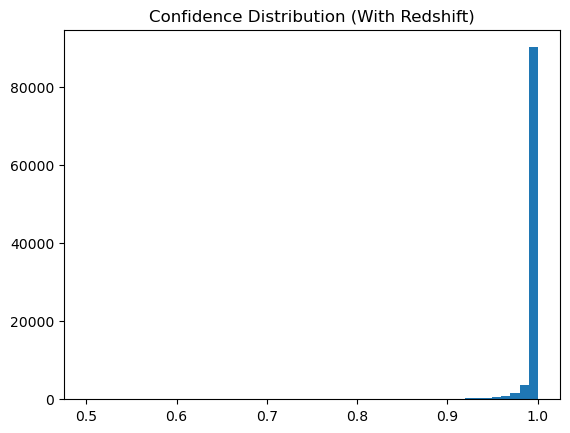

In [14]:
import matplotlib.pyplot as plt
plt.hist(df_new['confidence'], bins=50)
plt.title("Confidence Distribution (With Redshift)")
plt.show()

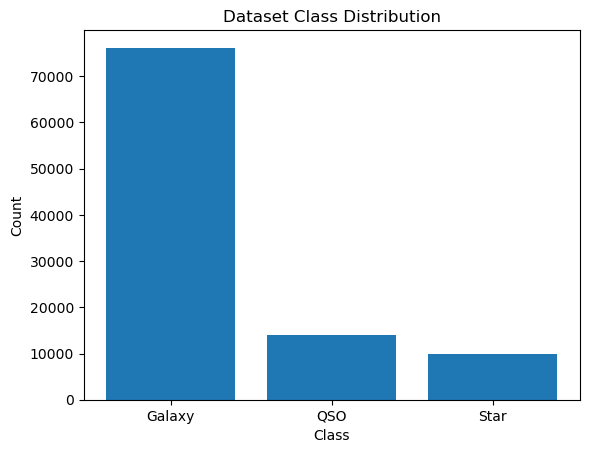

In [15]:
import matplotlib.pyplot as plt

counts = df_new['predicted_class'].value_counts()


labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

                                                               Without Redshift

In [38]:
model = joblib.load("xgb_no_redshift.pkl")

In [39]:
features = joblib.load("features_no_z.pkl")

df_input = df_new[features]   

In [40]:
pred = model.predict(df_input)
probs = model.predict_proba(df_input)

confidence = probs.max(axis=1)

df_new['predicted_class'] = pred
df_new['confidence'] = confidence

In [41]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}

df_new['predicted_class'] = df_new['predicted_class'].map(mapping)

print(df_new[['predicted_class', 'confidence']].head(10))

  predicted_class  confidence
0            Star    0.965547
1            Star    0.982043
2            Star    0.987484
3            Star    0.979906
4            Star    0.997320
5            Star    0.990591
6            Star    0.995285
7            Star    0.574337
8            Star    0.961295
9          Galaxy    0.877086


In [42]:
print(df_new['predicted_class'].value_counts())

predicted_class
Galaxy    75571
QSO       12929
Star      11500
Name: count, dtype: int64


In [43]:
print(df_new['confidence'].describe())

count    100000.000000
mean          0.930595
std           0.113825
min           0.339994
25%           0.926004
50%           0.984179
75%           0.993853
max           0.999912
Name: confidence, dtype: float64


In [44]:
high_conf = df_new[df_new['confidence'] > 0.9]
print(len(high_conf))

79243


In [45]:
df_new.groupby('predicted_class')['confidence'].mean()

predicted_class
Galaxy    0.952559
QSO       0.866282
Star      0.858570
Name: confidence, dtype: float32

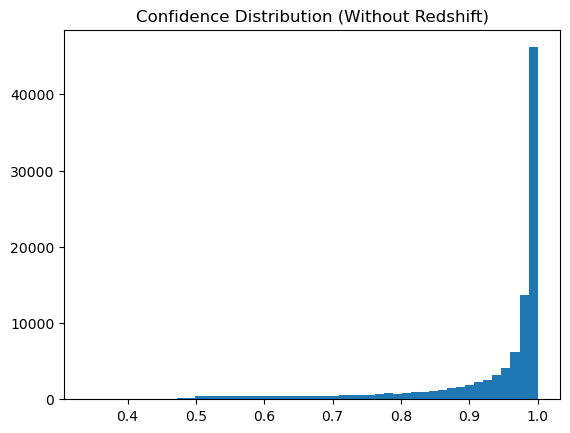

In [46]:
plt.hist(df_new['confidence'], bins=50)
plt.title("Confidence Distribution (Without Redshift)")
plt.show()

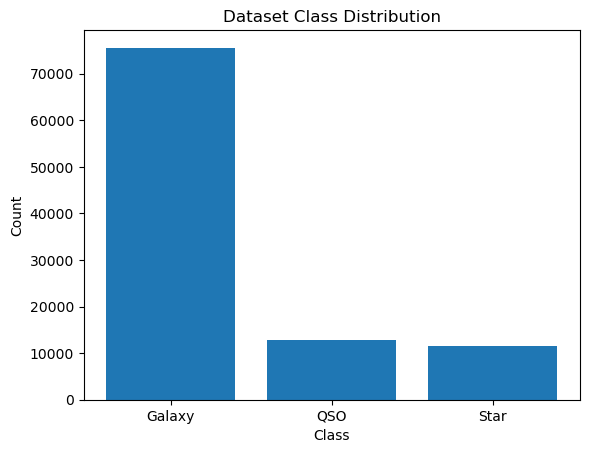

In [47]:
import matplotlib.pyplot as plt

counts = df_new['predicted_class'].value_counts()


labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()